In [15]:
!pip install pandas numpy scikit-learn nltk fastapi uvicorn joblib -q

import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

print(" Setup complete!")

 Setup complete!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [16]:
from google.colab import files
uploaded = files.upload()

Saving twitter_training.csv to twitter_training (3).csv
Saving twitter_validation.csv to twitter_validation (2).csv


In [17]:
column_names = ['id', 'entity', 'label', 'text']

train_df = pd.read_csv('twitter_training.csv', header=None, names=column_names)
val_df = pd.read_csv('twitter_validation.csv', header=None, names=column_names)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
train_df.head()

Train shape: (74682, 4)
Validation shape: (1000, 4)


,id,entity,label,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


label
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


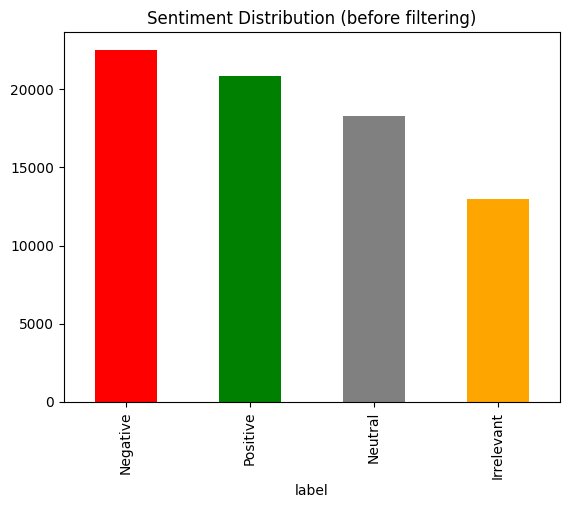

In [18]:
print(train_df['label'].value_counts())

train_df['label'].value_counts().plot(kind='bar', color=['red','green','gray','orange'])
plt.title("Sentiment Distribution (before filtering)")
plt.show()

In [19]:
train_df = train_df[train_df['label'] != 'Irrelevant'].reset_index(drop=True)
val_df = val_df[val_df['label'] != 'Irrelevant'].reset_index(drop=True)

print("After removing Irrelevant:")
print(train_df['label'].value_counts())

After removing Irrelevant:
label
Negative    22542
Positive    20832
Neutral     18318
Name: count, dtype: int64


In [20]:
train_df = train_df.dropna(subset=['text']).reset_index(drop=True)
val_df = val_df.dropna(subset=['text']).reset_index(drop=True)

print("Final train shape:", train_df.shape)
print("Final validation shape:", val_df.shape)

Final train shape: (61121, 4)
Final validation shape: (828, 4)


In [21]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text'] = val_df['text'].apply(clean_text)

train_df[['text', 'clean_text']].head(10)

,text,clean_text
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...
5,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...
6,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...
7,So I spent a couple of hours doing something f...,so i spent a couple of hours doing something f...
8,So I spent a few hours doing something for fun...,so i spent a few hours doing something for fun...
9,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...


In [22]:
train_df = train_df[train_df['clean_text'].str.strip() != ''].reset_index(drop=True)
val_df = val_df[val_df['clean_text'].str.strip() != ''].reset_index(drop=True)

print("Final train shape after cleaning:", train_df.shape)
print("Final validation shape after cleaning:", val_df.shape)

Final train shape after cleaning: (60835, 5)
Final validation shape after cleaning: (828, 5)


In [23]:
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

train_df['processed_text'] = train_df['clean_text'].apply(preprocess_text)
val_df['processed_text'] = val_df['clean_text'].apply(preprocess_text)

train_df[['clean_text', 'processed_text']].head(10)

,clean_text,processed_text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,i am coming to the borders and i will kill you...,coming border kill
2,im getting on borderlands and i will kill you all,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands and i will murder yo...,im getting borderland murder
5,im getting into borderlands and i can murder y...,im getting borderland murder
6,so i spent a few hours making something for fu...,spent hour making something fun dont know huge...
7,so i spent a couple of hours doing something f...,spent couple hour something fun dont know im h...
8,so i spent a few hours doing something for fun...,spent hour something fun dont know im huge bor...
9,so i spent a few hours making something for fu...,spent hour making something fun dont know huge...


In [24]:
train_df = train_df[train_df['processed_text'].str.strip() != ''].reset_index(drop=True)
val_df = val_df[val_df['processed_text'].str.strip() != ''].reset_index(drop=True)

print("Final shapes -> Train:", train_df.shape, "| Val:", val_df.shape)

Final shapes -> Train: (59705, 6) | Val: (827, 6)


In [25]:
X_train_text = train_df['processed_text']
y_train = train_df['label']

X_val_text = val_df['processed_text']
y_val = val_df['label']

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train = tfidf.fit_transform(X_train_text)
X_val = tfidf.transform(X_val_text)

print("Train feature matrix shape:", X_train.shape)
print("Validation feature matrix shape:", X_val.shape)

Train feature matrix shape: (59705, 5000)
Validation feature matrix shape: (827, 5000)


In [26]:
model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
model.fit(X_train, y_train)

print(" Model training complete!")

 Model training complete!


In [27]:
sample_preds = model.predict(X_val[:5])
print("Predicted:", sample_preds)
print("Actual:   ", y_val[:5].values)

Predicted: ['Neutral' 'Negative' 'Negative' 'Neutral' 'Negative']
Actual:    ['Neutral' 'Negative' 'Negative' 'Neutral' 'Negative']


In [28]:
y_pred = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print(f" Accuracy: {accuracy*100:.2f}%")


precision = precision_score(y_val, y_pred, average='weighted')
recall = recall_score(y_val, y_pred, average='weighted')
f1 = f1_score(y_val, y_pred, average='weighted')

print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1 Score: {f1*100:.2f}%")

 Accuracy: 84.52%
Precision: 85.02%
Recall: 84.52%
F1 Score: 84.50%


In [29]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

    Negative       0.79      0.89      0.83       265
     Neutral       0.90      0.77      0.83       285
    Positive       0.86      0.88      0.87       277

    accuracy                           0.85       827
   macro avg       0.85      0.85      0.84       827
weighted avg       0.85      0.85      0.84       827



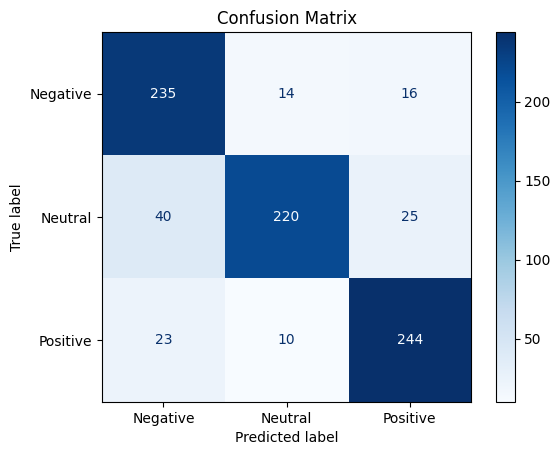

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [34]:
joblib.dump(model, 'model.pkl')
joblib.dump(tfidf, 'vectorizer.pkl')

print(" Model and vectorizer saved!")

 Model and vectorizer saved!


In [35]:
from google.colab import files
files.download('model.pkl')
files.download('vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import os
print("model.pkl size:", os.path.getsize('model.pkl'), "bytes")
print("vectorizer.pkl size:", os.path.getsize('vectorizer.pkl'), "bytes")

model.pkl size: 121039 bytes
vectorizer.pkl size: 187287 bytes
